In [19]:
import pandas as pd
import numpy as np
import matplotlib as plt3
import tensorflow as tf
from tensorflow import keras

# Modelos
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Validación
from sklearn.model_selection import GroupKFold, cross_validate

# Métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [20]:
df = pd.read_excel('archivo.xlsx')
df

,ID_PE,COD_NI,DES_NI,ID_MAT,COD_EST,ID_SEX,COD_PRO,ED_EST,N1,N2
0,59,7,SEPTIMO NIVEL,70,27441,1,17,23,8,10
1,58,8,OCTAVO NIVEL,79,27438,1,17,24,8,9
2,59,9,NOVENO NIVEL,33,27438,1,17,25,7,7
3,59,9,NOVENO NIVEL,72,27438,1,17,25,6,8
4,57,7,SEPTIMO NIVEL,97,27438,1,17,24,4,6
...,...,...,...,...,...,...,...,...,...,...
18599,56,9,NOVENO NIVEL,33,26020,2,6,36,5,6
18600,55,11,DECIMO PRIMER NIVEL,166,26019,2,6,25,8,9
18601,55,11,DECIMO PRIMER NIVEL,164,26019,2,6,25,7,7
18602,57,13,DECIMO TERCER NIVEL,184,26116,2,17,25,8,8


In [21]:
# Supongamos que cargamos el archivo generado
# df = pd.read_excel("datos_sinteticos_rendimiento_academico.xlsx")

def preparar_datos_para_lmm(df_raw):
    df_proc = df_raw.copy()
    
    # === PASO 1: Homogeneizar las escalas de las notas ===
    # Llevamos ambas notas a una escala estándar (base 10) para que sean comparables
    df_proc['N1_C'] = (df_proc['N1']*10/8).astype(int)
    # Opcional: Crear una nota final combinada (ej. promedio de ambas)
    df_proc['SUM'] = df_proc['N1_C'] + df_proc['N2']

    # === PASO 2: Transformar variables de texto a numéricas (Codificación) ===
    # Para provincias, asignaturas y sexo (Label Encoding)
    le_province = LabelEncoder()
    df_proc['COD_PRO'] = le_province.fit_transform(df_proc['COD_PRO'])
    
    le_subject = LabelEncoder()
    df_proc['ID_MAT'] = le_subject.fit_transform(df_proc['ID_MAT'])

    le_sx = LabelEncoder()
    df_proc['ID_SEX'] = le_sx.fit_transform(df_proc['ID_SEX'])
    
    # Extraer el número del nivel curricular (convertir "Nivel 7" en el entero 7)
    df_proc['COD_NI'] = df_proc['COD_NI'].astype('category').cat.codes
    
    # Extraer el número del periodo (convertir "Periodo 1" en el entero 1)
    df_proc['ID_PE'] = df_proc['ID_PE'].astype('category').cat.codes

    # === PASO 3: Asegurar formatos de los identificadores ===
    # El ID del estudiante debe ser tratado como un string o categoría para el efecto aleatorio
    # Codificación ordinal del periodo académico
    
    df_proc['COD_EST'] = df_proc['COD_EST'].astype('category').cat.codes
    
    return df_proc

# Ejecutamos el tratamiento
df_listo = preparar_datos_para_lmm(df)
print("Data processed successfully. Columns ready for modeling:")
print(df_listo[['ID_PE','COD_NI','ID_MAT','COD_PRO','ED_EST','SUM']].head())

Data processed successfully. Columns ready for modeling:
   ID_PE  COD_NI  ID_MAT  COD_PRO  ED_EST  SUM
0      6       0       4       16      23   20
1      5       1       7       16      24   19
2      6       2       1       16      25   15
3      6       2       6       16      25   15
4      4       0       8       16      24   11


In [22]:
df1 = df_listo.copy()
df1

,ID_PE,COD_NI,DES_NI,ID_MAT,COD_EST,ID_SEX,COD_PRO,ED_EST,N1,N2,N1_C,SUM
0,6,0,SEPTIMO NIVEL,4,1263,0,16,23,8,10,10,20
1,5,1,OCTAVO NIVEL,7,1260,0,16,24,8,9,10,19
2,6,2,NOVENO NIVEL,1,1260,0,16,25,7,7,8,15
3,6,2,NOVENO NIVEL,6,1260,0,16,25,6,8,7,15
4,4,0,SEPTIMO NIVEL,8,1260,0,16,24,4,6,5,11
...,...,...,...,...,...,...,...,...,...,...,...,...
18599,3,2,NOVENO NIVEL,1,195,1,5,36,5,6,6,12
18600,2,4,DECIMO PRIMER NIVEL,17,194,1,5,25,8,9,10,19
18601,2,4,DECIMO PRIMER NIVEL,15,194,1,5,25,7,7,8,15
18602,4,6,DECIMO TERCER NIVEL,28,267,1,16,25,8,8,10,18


In [23]:
# Vista general
print(df1.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18604 entries, 0 to 18603
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   ID_PE    18604 non-null  int8  
 1   COD_NI   18604 non-null  int8  
 2   DES_NI   18604 non-null  object
 3   ID_MAT   18604 non-null  int64 
 4   COD_EST  18604 non-null  int16 
 5   ID_SEX   18604 non-null  int64 
 6   COD_PRO  18604 non-null  int64 
 7   ED_EST   18604 non-null  int64 
 8   N1       18604 non-null  int64 
 9   N2       18604 non-null  int64 
 10  N1_C     18604 non-null  int64 
 11  SUM      18604 non-null  int64 
dtypes: int16(1), int64(8), int8(2), object(1)
memory usage: 1.3+ MB
None


In [24]:
cardinalidad = df1.nunique().sort_values(ascending=False)
print(cardinalidad)

COD_EST    1264
ID_MAT       30
ED_EST       25
COD_PRO      22
SUM          19
N2           11
N1_C          9
N1            9
DES_NI        7
COD_NI        7
ID_PE         7
ID_SEX        2
dtype: int64


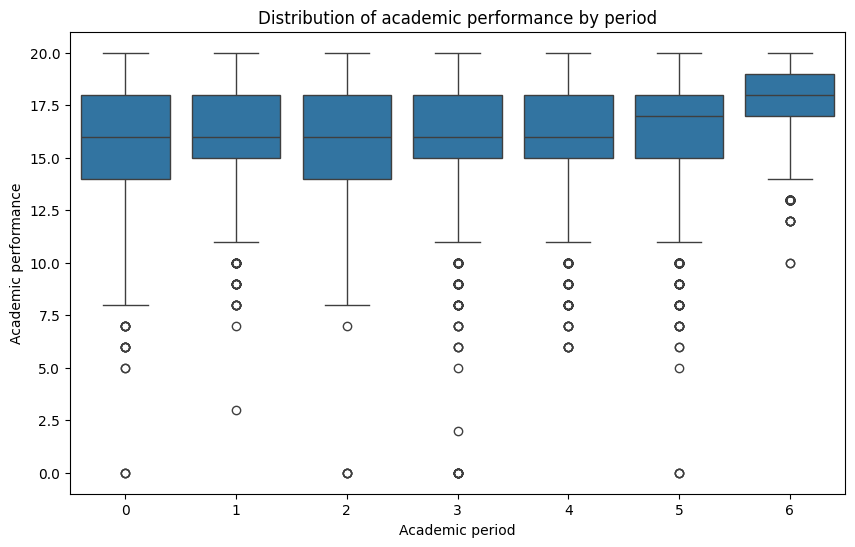

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df1,
    x="ID_PE",
    y="SUM"
)
plt.xlabel("Academic period")
plt.ylabel("Academic performance")
plt.title("Distribution of academic performance by period")
plt.show()

In [26]:
# modelo lineal mixto
import statsmodels.formula.api as smf
import statsmodels.api as sm

# 1. Definición de la estructura del modelo
# Efectos Fijos: periodo_num, nivel_num, edad, sexo_coded, provincia_coded
# Variable Dependiente: nota_final (escalada a base 10)

formula = "SUM ~ ID_PE + COD_NI + ED_EST + C(ID_SEX) + C(COD_PRO) "

# 3. Construcción y ajuste del modelo
modelo_mixto = smf.mixedlm(
    formula, 
    data=df1, 
    groups=df1["COD_EST"]
)
resultado_mixto = modelo_mixto.fit()

# 4. Mostrar el reporte de resultados
print(resultado_mixto.summary())

           Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: SUM        
No. Observations:   18604   Method:             REML       
No. Groups:         1264    Scale:              4.0570     
Min. group size:    1       Log-Likelihood:     -40479.6238
Max. group size:    30      Converged:          Yes        
Mean group size:    14.7                                   
-----------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept        17.417    1.012 17.212 0.000 15.434 19.400
C(ID_SEX)[T.1]   -0.193    0.078 -2.472 0.013 -0.346 -0.040
C(COD_PRO)[T.1]  -1.204    0.967 -1.245 0.213 -3.098  0.691
C(COD_PRO)[T.2]  -1.781    1.024 -1.739 0.082 -3.787  0.226
C(COD_PRO)[T.3]  -1.634    0.993 -1.645 0.100 -3.581  0.313
C(COD_PRO)[T.4]  -1.384    0.961 -1.440 0.150 -3.269  0.500
C(COD_PRO)[T.5]  -1.289    0.955 -1.350 0.177 -3.16

In [35]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# =====================================================================
# 1. FUNCIÓN MATEMÁTICA CORREGIDA: R² MARGINAL Y CONDICIONAL
# =====================================================================
def calcular_r2_nakagawa(model):
    # Varianza efectos fijos
    var_fixed = np.var(model.fittedvalues)

    # Varianza efectos aleatorios
    try:
        var_random = np.sum(np.diag(model.cov_re))
    except:
        var_random = np.sum(np.diag(model.cov_re.values))

    # Varianza residual
    var_residual = model.scale

    # R² marginal
    r2_marginal = var_fixed / (var_fixed + var_random + var_residual)

    # R² condicional
    r2_conditional = (var_fixed + var_random) / (var_fixed + var_random + var_residual)

    return r2_marginal, r2_conditional
# =====================================================================
# 2. AJUSTE DEL MODELO COMPLETO BASE
# =====================================================================
# Estructura exacta de tus variables con envoltura C() para mitigar LabelEncoder
model_full = smf.mixedlm(
    formula,
    data=df1,
    groups=df1["COD_EST"]
    
).fit(reml=True)


r2_m_completo, r2_c_completo = r2_mixed_model(model_full)

print("\n" + "="*50)
print(f"R² Marginal (Efectos Fijos):    {r2_m_completo:.6f}")
print(f"R² Condicional (Modelo Total):  {r2_c_completo:.6f}")
print(f"Varianza de Efectos Aleatorios: {(r2_c_completo - r2_m_completo):.6f}")
print("="*50 + "\n")

# =====================================================================
# 3. BUCLE DE COEFICIENTES SEMI-PARCIALES MARGINALES (INCREMENTALES)
# =====================================================================
from statsmodels.formula.api import mixedlm

def semi_partial_r2(full_model, reduced_model):
    return (reduced_model.llf - full_model.llf) * -2 / full_model.nobs
predictores = [
    'ID_PE',
    'COD_NI',
    'ED_EST',
    'C(ID_SEX)',
    'C(COD_PRO)'
]
 
sr2 = {}

for var in predictores:
    formula_reducida = (
        'SUM ~ ' +
        ' + '.join([v for v in predictores if v != var])
    )

    modelo_reducido = mixedlm(
        formula_reducida,
        data=df1,
        groups=df1['COD_EST']
    ).fit(reml=True)

    sr2[var] = semi_partial_r2(resultado_mixto, modelo_reducido)

print(sr2)




R² Marginal (Efectos Fijos):    0.296787
R² Condicional (Modelo Total):  0.472984
Varianza de Efectos Aleatorios: 0.176197

{'ID_PE': np.float64(0.02571210612680368), 'COD_NI': np.float64(0.04399274966887802), 'ED_EST': np.float64(0.0013216211313428448), 'C(ID_SEX)': np.float64(0.00015337537800366003), 'C(COD_PRO)': np.float64(0.0008510397682143137)}


Iniciando validación cruzada y cálculo de SHAP por grupos...
-> Evaluando e interpretando: Ridge
-> Evaluando e interpretando: MLP (Neural Network)
-> Evaluando e interpretando: XGBoost
-> Evaluando e interpretando: Random Forest

=== RENDIMIENTO DE LOS MODELOS ACTUALIZADOS (CON EDAD) ===
              Modelo  R² Promedio  R² Desv. Est.  RMSE Promedio
               Ridge     0.257949       0.010217       2.201921
MLP (Neural Network)     0.445974       0.018412       1.903046
             XGBoost     0.534281       0.021896       1.744875
       Random Forest     0.543140       0.020487       1.728498

Generando gráficos summary_plot de SHAP...


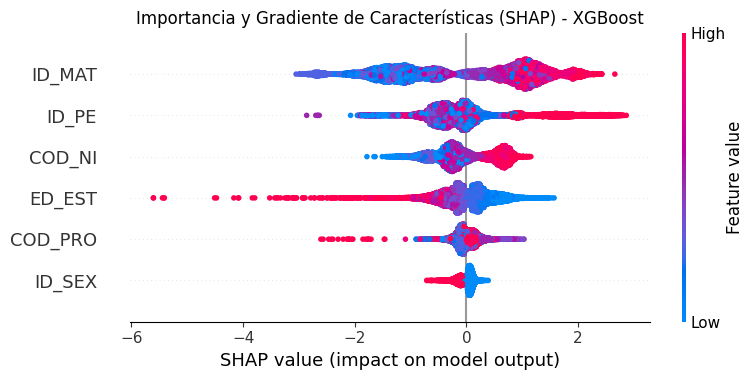

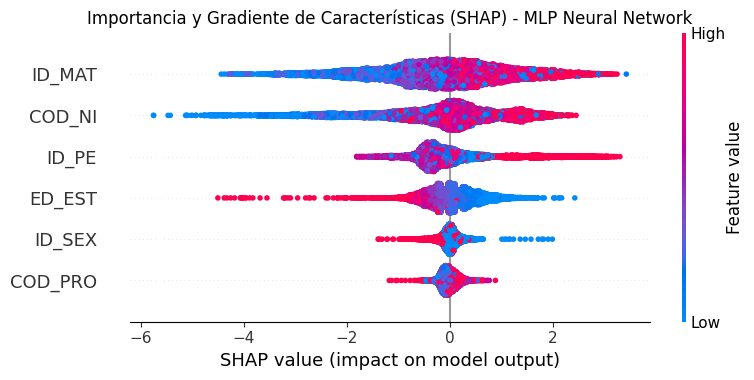

In [40]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
# Preprocessing
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
# Modelos
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor


# Validación y Métricas
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# =====================================================================
# 1. PREPARACIÓN DE VARIABLES (Incluyendo Edad y validando tipos)
# =====================================================================
# Variable objetivo continua
y = df1['SUM'].values 
grupos = df1['COD_EST'].values

# Lista de características actualizada con la variable de edad ('ED_EST')
features = ['ID_PE','COD_NI','ID_MAT', 'ED_EST', 'ID_SEX', 'COD_PRO']
X = df1[features].copy()

# =====================================================================
# 2. INICIALIZACIÓN DE MODELOS
# =====================================================================
modelos = {
    "Ridge": Ridge(alpha=1.0),
    "MLP (Neural Network)": MLPRegressor (hidden_layer_sizes=(64, 32), 
                            activation = "relu",
                            solver = "adam",
                            max_iter=500, 
                            random_state=42),
    "XGBoost": XGBRegressor (n_estimators=300,
                            max_depth = 6, 
                            learning_rate=0.05,
                            subsample = 0.8,
                            colsample_bytree = 0.8,
                            objective = "reg:squarederror",  
                            random_state=42),
    "Random Forest": RandomForestRegressor (n_estimators=300,
                            max_depth=15,
                            min_samples_leaf = 20, 
                            random_state=42, 
                            n_jobs=-1)

}

# =====================================================================
# 3. EVALUACIÓN CON GROUPKFOLD Y EXTRACCIÓN SHAP
# =====================================================================
gkf = GroupKFold(n_splits=5)
resultados_metricas = []

# Matrices globales para almacenar los impactos SHAP alineados con X
shap_valores_globales = {
    "Ridge": np.zeros(X.shape),
    "XGBoost": np.zeros(X.shape),
    "Random Forest": np.zeros(X.shape),
    "MLP (Neural Network)": np.zeros(X.shape)
}

print("Iniciando validación cruzada y cálculo de SHAP por grupos...")

for nombre_modelo, modelo in modelos.items():
    r2_folds = []
    rmse_folds = []
    
    print(f"-> Evaluando e interpretando: {nombre_modelo}")
    
    for train_idx, test_idx in gkf.split(X, y, groups=grupos):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Escalado interno por Fold (Afecta positivamente a Edad, Niveles y Periodos)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Convertir a DataFrame para que SHAP mantenga los nombres de las columnas
        X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=features)
        X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=features)
        
        # Ajustar el modelo
        modelo.fit(X_train_scaled_df, y_train)
        
        # Evaluar
        preds = modelo.predict(X_test_scaled_df)
        r2_folds.append(r2_score(y_test, preds))
        rmse_folds.append(np.sqrt(mean_squared_error(y_test, preds)))
        
        # -----------------------------------------------------------------
        # Extracción de SHAP con parsimonia de datos (Muestra de DataFrame)
        # -----------------------------------------------------------------
        X_background_df = X_train_scaled_df.sample(n=min(50, len(X_train_scaled_df)), random_state=42)
        
        if nombre_modelo in ["XGBoost", "Random Forest"]:
            explainer = shap.TreeExplainer(modelo)
            sv = explainer(X_test_scaled_df).values
            if len(sv.shape) == 3: sv = sv[:, :, 0]
                
        elif nombre_modelo == "Ridge":
            explainer = shap.LinearExplainer(modelo, X_background_df)
            sv = explainer.shap_values(X_test_scaled_df)
            
        elif nombre_modelo == "MLP (Neural Network)":
            explainer = shap.KernelExplainer(modelo.predict, X_background_df)
            sv = explainer.shap_values(X_test_scaled_df, silent=True)
        
        # Guardar porción en la matriz global
        shap_valores_globales[nombre_modelo][test_idx] = sv

    # Métricas consolidadas
    resultados_metricas.append({
        "Modelo": nombre_modelo,
        "R² Promedio": np.mean(r2_folds),
        "R² Desv. Est.": np.std(r2_folds),
        "RMSE Promedio": np.mean(rmse_folds)
    })

# =====================================================================
# 4. TABLA DE RENDIMIENTO FINAL
# =====================================================================
df_resultados = pd.DataFrame(resultados_metricas)
print("\n=== RENDIMIENTO DE LOS MODELOS ACTUALIZADOS (CON EDAD) ===")
print(df_resultados.to_string(index=False))

# =====================================================================
# 5. GRÁFICOS DE EXPLICABILIDAD GLOBAL (SHAP)
# =====================================================================
# Escalamos X de forma global únicamente con fines de visualización en los ejes
scaler_global = StandardScaler()
X_scaled_global = pd.DataFrame(scaler_global.fit_transform(X), columns=features)

print("\nGenerando gráficos summary_plot de SHAP...")

# Gráfico para XGBoost (Formato completo de dispersión de abejas / Beeswarm)
plt.figure(figsize=(10, 5))
plt.title("Importancia y Gradiente de Características (SHAP) - XGBoost")
shap.summary_plot(shap_valores_globales["XGBoost"], X_scaled_global)

# Gráfico para la Red Neuronal MLP
plt.figure(figsize=(10, 5))
plt.title("Importancia y Gradiente de Características (SHAP) - MLP Neural Network")
shap.summary_plot(shap_valores_globales["MLP (Neural Network)"], X_scaled_global)

In [ ]:
import numpy as np
import pandas as pd

# =====================================================================
# 1. EXTRACCIÓN DE PREDICCIONES Y VALORES SHAP (Para todo el dataset)
# =====================================================================
# Nota: Suponemos que ya ejecutaste el bucle GroupKFold anterior.
# Recuperamos el modelo entrenado de XGBoost y su matriz SHAP acumulada.

# 1.1 Volvemos a escalar el dataset completo para generar las predicciones globales
scaler_global = StandardScaler()
X_scaled_global = pd.DataFrame(scaler_global.fit_transform(X), columns=features)

# 1.2 Generamos las predicciones continuas del modelo XGBoost para cada registro
# (Usamos las predicciones acumuladas o el modelo final entrenado)
predicciones_notas = modelos["XGBoost"].predict(X_scaled_global)

# =====================================================================
# 2. CONSTRUCCIÓN DEL DATAFRAME DE ALERTAS ANALÍTICAS
# =====================================================================
# Creamos un DataFrame que asocie la identidad del alumno con su riesgo y sus SHAP
df_alertas = pd.DataFrame({
    'COD_EST': df1['COD_EST'].values,
    'Nota_Predicha': predicciones_notas,
    'Riesgo': np.where(predicciones_notas <= 14.0, 'ALTO RIESGO', 'BAJO RIESGO')
})

# Extraemos la matriz SHAP de XGBoost calculada previamente
# Cada columna de esta matriz nos dice cuántos puntos sumó o restó esa variable a la nota del alumno
shap_xgb = shap_valores_globales["XGBoost"]

# Añadimos los impactos individuales de cada variable al DataFrame de alertas
for i, var in enumerate(features):
    df_alertas[f'Impacto_{var}'] = shap_xgb[:, i]

# =====================================================================
# 3. ALGORITMO DE DIAGNÓSTICO AUTOMÁTICO (Regla de Negocio XAI)
# =====================================================================
def diagnosticar_causa_principal(row):
    """
    Analiza los impactos SHAP del estudiante y devuelve la variable 
    que más redujo su nota final esperada.
    """
    if row['Riesgo'] == 'BAJO RIESGO':
        return 'Sin riesgo aparente'
    
    # Filtrar solo las columnas que representan impactos SHAP de las variables
    columnas_impacto = [f'Impacto_{var}' for var in features]
    impactos = row[columnas_impacto]
    
    # El impacto más negativo (el valor mínimo) es la causa principal del riesgo
    causa_columna = impactos.astype(float).idxmin()
    
    # Limpiamos el nombre de la variable para el reporte formal
    variable_critica = causa_columna.replace('Impacto_', '')
    
    # Mapeo de variables a mensajes institucionales legibles
    mensajes_diagnostico = {
        'ID_MAT': 'Dificultad crítica intrínseca de la asignatura seleccionada.',
        'ED_EST': 'Factor etario: Estudiante requiere tutoría adaptada a su cohorte cronológica.',
        'ID_PE': 'Desadaptación temporal o rezago en la secuencia de periodos académicos.',
        'COD_NI': 'Brecha de competencias en la transición al nivel curricular actual.',
        'ID_SEX': 'Disparidad de rendimiento asociada a brechas de género en el área.',
        'COD_PRO': 'Vulnerabilidad por condiciones de origen geográfico o desplazamiento.'
    }
    
    return mensajes_diagnostico.get(variable_critica, 'Combinación multifactorial de riesgo.')

# Aplicamos el diagnóstico fila por fila
df_alertas['Diagnostico_Tutor'] = df_alertas.apply(diagnosticar_causa_principal, axis=1)

# =====================================================================
# 4. FILTRADO Y EXPORTACIÓN DEL REPORTE DE ALERTAS TEMPRANAS
# =====================================================================
# Aislamos únicamente a los estudiantes que requieren intervención prioritaria
reporte_prioritario = df_alertas[df_alertas['Riesgo'] == 'ALTO RIESGO'].copy()

# Ordenamos el reporte: los estudiantes con las notas predichas más bajas van primero
reporte_prioritario = reporte_prioritario.sort_values(by='Nota_Predicha', ascending=True)

print(f"Alerta generada con éxito. Se detectaron {len(reporte_prioritario)} registros en riesgo pedagógico.")
print("\n--- MUESTRA DEL REPORTE DE ALERTAS INSTITUCIONALES ---")
print(reporte_prioritario[['COD_EST', 'Nota_Predicha', 'Diagnostico_Tutor']].head(10).to_string(index=False))

# Opcional: Exportar a Excel para enviar al departamento de Tutorías o Dirección de Carrera
# reporte_prioritario.to_excel('Alertas_Riesgo_Academico_SHAP.xlsx', index=False)

In [ ]:
# evaluación comparativa de modelos
results = []

for name, model in models.items():
    
    scores = cross_validate(
        model,
        X, y,
        groups=groups,
        cv=cv,
        scoring=["neg_mean_absolute_error", "neg_root_mean_squared_error", "r2"],
        n_jobs=-1
    )
    
    results.append({
        "Modelo": name,
        "MAE": -scores["test_neg_mean_absolute_error"].mean(),
        "RMSE": -scores["test_neg_root_mean_squared_error"].mean(),
        "R2": scores["test_r2"].mean()
    })

results_df = pd.DataFrame(results)
print(results_df)


In [ ]:
best_model = xgb_model  # ejemplo
best_model.fit(X, y)

df_modelo["y_pred"] = best_model.predict(X)
df_modelo["error"] = df_modelo[TARGET] - df_modelo["y_pred"]

error_by_period = df_modelo.groupby("PE_ORD")["error"].agg(
    MAE=lambda x: np.mean(np.abs(x)),
    RMSE=lambda x: np.sqrt(np.mean(x**2)),
    Mean_Error="mean",
    Std_Error="std"
)

print(error_by_period)



In [ ]:
from sklearn.model_selection import GroupKFold, cross_val_predict
# Generamos predicciones "fuera de la bolsa" (out-of-fold) para analizar errores

y_pred = cross_val_predict(xgb_model, X_clean, y, groups=groups, cv=cv)

# 4. Creación de DataFrame de Análisis
error_analysis = X.copy()
error_analysis['real'] = y
error_analysis['predicho'] = y_pred
error_analysis['error_abs'] = np.abs(y - y_pred)

# --- ANALISIS DE PERFILES DIFÍCILES ---
# Agrupamos por procedencia para ver dónde falla más el modelo
analisis_perfil = error_analysis.groupby('COD_PRO')['error_abs'].mean()
print("Average error by origin:\n", analisis_perfil)

# Agrupamos por rangos de edad (ya que no es normal)
error_analysis['rango_edad'] = pd.cut(error_analysis['ED_EST'], bins=[0, 18, 22, 30, 50])
analisis_edad = error_analysis.groupby('rango_edad', observed=True)['error_abs'].mean()
print("\nAverage error by age range:\n", analisis_edad)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Suponiendo que ya tienes 'error_analysis' del paso anterior
# error_analysis contiene: ['real', 'predicho', 'error_abs', 'edad', etc.]

plt.figure(figsize=(15, 6))

# --- GRÁFICO 1: REAL VS PREDICHO ---
plt.subplot(1, 2, 1)
sns.scatterplot(data=error_analysis, x='real', y='predicho', alpha=0.6)
# Línea de identidad (lo que sería una predicción perfecta)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r', lw=2)
plt.title('Actual Values vs. Predictions\n(Proximity to the red line indicates accuracy.)')
plt.xlabel('Actual Performance')
plt.ylabel('Predicted Performance')

# --- GRÁFICO 2: HISTOGRAMA DE RESIDUOS (ERRORES) ---
plt.subplot(1, 2, 2)
# El residuo es la diferencia con signo: (Real - Predicho)
error_analysis['residuo'] = error_analysis['real'] - error_analysis['predicho']
sns.histplot(error_analysis['residuo'], kde=True, color='purple')
plt.axvline(0, color='black', linestyle='--')
plt.title('Distribution of Errors (Residuals)\n(Should center on 0)')
plt.xlabel('Error (Difference)')


plt.tight_layout()
plt.show()

# --- GRÁFICO 3: ERROR POR PERFIL (BOXPLOT) ---
plt.figure(figsize=(10, 5))
sns.boxplot(data=error_analysis, x='COD_PRO', y='error_abs', hue='ID_SEX')
plt.title('Distribution of Absolute Error by Origin and Gender')
plt.ylabel('Magnitude of Error')
plt.show()


In [ ]:
df_numeric = df1.select_dtypes(include=[np.number])

# 3. Cálculo de la Correlación de Spearman (Ideal para datos no normales)
corr_matrix = df_numeric.corr(method='spearman')

# 4. Visualización con Mapa de Calor (Heatmap)
plt.figure(figsize=(12, 10))

# Creamos una máscara para ver solo la mitad inferior (evita duplicados)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True,          # Muestra los números
            fmt=".2f",           # Dos decimales
            cmap='RdBu_r',       # Rojo para negativo, Azul para positivo
            center=0, 
            linewidths=.5)

plt.title('Matriz de Correlación de Spearman\n(Justificación de Selección de Variables)')
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.utils import resample
from sklearn.metrics import r2_score

# Configuración del Bootstrap
n_iterations = 1000
stats = []

# Supongamos que y_test y y_pred son tus resultados del mejor modelo (XGBoost)
# Para este ejemplo, creamos un DataFrame con ambos
data_res = pd.DataFrame({'real': y, 'pred': y_pred})

for i in range(n_iterations):
    # Generar una muestra aleatoria con reemplazo
    sample = resample(data_res)
    # Calcular la métrica en esa muestra
    score = r2_score(sample['real'], sample['pred'])
    stats.append(score)

# Calcular Intervalo de Confianza al 95%
lower = np.percentile(stats, 2.5)
upper = np.percentile(stats, 97.5)

print(f"Intervalo de Confianza (95%) para R2: [{lower:.4f} - {upper:.4f}]")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cálculo de residuos
residuos = y - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuos, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Uncertainty Analysis: Residuals vs. Predictions')
plt.xlabel('Predicted Value (Yield)')
plt.ylabel('Residual (Error)')

plt.show()

In [ ]:
# analisis de anova de un factor para datos no balanceados
import statsmodels.api as sm
from statsmodels.formula.api import ols

modelo_proc = ols(
    'SUM ~ C(COD_PRO)',
    data=df1
).fit()

anova_proc = sm.stats.anova_lm(modelo_proc, typ=2)
print(anova_proc)


In [ ]:
eta_squared = (
    anova_proc.loc['C(COD_PRO)', 'sum_sq'] /
    anova_proc['sum_sq'].sum()
)

print(f"Eta cuadrado = {eta_squared:.4f}")

In [ ]:
from scipy.stats import spearmanr

rho, p_val = spearmanr(df1['ED_EST'], df1['SUM'])
print(f"Spearman ρ = {rho:.3f}, p-valor = {p_val:.5e}")

In [ ]:
# agrupo los datos por codigo del estudiante
groups = df1['COD_EST']
groups

In [ ]:
# obtengo la variabilidad por nivel  
cv_asig_per = (
    df1.groupby(['PE_ORD', 'COD_NI'])['SUM']
      .agg(mean='mean', std='std', n='count')
      .query('n >= 30')
)

cv_asig_per['cv'] = (cv_asig_per['std'] / cv_asig_per['mean'])*100
cv_asig_per = cv_asig_per.sort_values('cv', ascending=False)
cv_asig_per

In [ ]:
# Comparación de rendimiento por período (no paramétrica)
from scipy.stats import kruskal

grupos_periodo = [
    g['SUM']
    for _, g in df1.groupby('PE_ORD')
]

h, p = kruskal(*grupos_periodo)
print("Kruskal por período:", p)

#grupos_periodo


In [ ]:
student_stats = (
    df1.groupby('COD_EST')['SUM']
      .agg(['mean', 'std', 'count'])
      .reset_index()
      .rename(columns={
          'mean': 'EST_MEAN',
          'std': 'EST_STD',
          'count': 'EST_N'
      })
)

df1 = df1.merge(student_stats, on='COD_EST', how='left')

In [ ]:
df1

In [ ]:
num_vars = [
    'ED_EST', 'EST_MEAN', 'EST_STD', 'EST_N'
]

cat_vars = [
    'PE_ORD','COD_NI','COD_MAT','ID_SEX', 'COD_PRO',
     
]


In [ ]:
# Pipeline para preprocesamiento de variables
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [ ]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [ ]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        min_frequency=0.02  # controla cardinalidad
    ))
])

In [ ]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_vars),
    ('cat', cat_pipeline, cat_vars)
])


In [ ]:
full_pipeline = Pipeline([
    ('preprocess', preprocessor)
])


In [ ]:
from sklearn.model_selection import GroupKFold

X = df1[num_vars + cat_vars]
y = df1['SUM']
groups = df1['COD_EST']

gkf = GroupKFold(n_splits=5)


In [ ]:
# Estadistica descriptiva por periodo académico

rendimiento_periodo = (
    df1.groupby('PE_ORD')['SUM']
    .agg(["mean", "std", "count",("cv", lambda x: (x.std() / x.mean()) * 100 if x.mean() != 0 else 0)])
    .reset_index()
)
rendimiento_periodo

In [ ]:
import matplotlib.pyplot as plt

plt.plot(
    rendimiento_periodo['PE_ORD'],
    rendimiento_periodo['mean'],
    marker="o"
)
plt.xlabel("Academic Period")
plt.ylabel("Average Grade")
plt.title("Evolution of Academic Performance by Period")
plt.xticks(rotation=45)
plt.show()

In [ ]:
dist_periodo = (
    df1.groupby('PE_ORD')[['N1_C','N2','SUM']]
    .agg(["min", "max","mean", "std",  "count"])
)
dist_periodo

In [ ]:
# Analisis de la variabilidad entre asignaturas y periodos 
variabilidad_asignatura_periodo = (
    df1.groupby(['PE_ORD','COD_MAT'])[['N1_C', 'N2']]
    .agg(["mean", "std", ("cv", lambda x: (x.std() / x.mean()) * 100 if x.mean() != 0 else 0),"count", ("un_7", lambda x: (x <= 7.0).sum())
    ])
    .reset_index()
)

variabilidad_asignatura_periodo

In [ ]:
# Analisis de variabilidad por una determinada asignatura
#
comparacion_periodos = (
    df1[df1['COD_MAT'] == "MFO1306"]
    .groupby('PE_ORD')['SUM']
    .agg(["min","max","mean", "std", "count"])
    .reset_index()
)
comparacion_periodos["cv"] = (
    (comparacion_periodos["std"] /
    comparacion_periodos["mean"])*100
)
comparacion_periodos

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.errorbar(
    comparacion_periodos['PE_ORD'],
    comparacion_periodos["mean"],
    yerr=comparacion_periodos["std"],
    fmt='o-'
)
plt.xlabel("Academic Period")
plt.ylabel("Average Grade")
plt.title("Performance Evolution by Period (MFO1306)")
plt.show()

In [ ]:
#
comparacion_periodos = (
    df1[df1['COD_MAT'] == "MFO1008"]
    .groupby('PE_ORD')['SUM']
    .agg(["mean", "std", "count"])
    .reset_index()
)
comparacion_periodos["cv"] = (
    (comparacion_periodos["std"] /
    comparacion_periodos["mean"])*100
)

comparacion_periodos

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.errorbar(
    comparacion_periodos['PE_ORD'],
    comparacion_periodos["mean"],
    yerr=comparacion_periodos["std"],
    fmt='o-'
)
plt.xlabel("Academic Period")
plt.ylabel("Average Grade")
plt.title("Performance Evolution by Period (MFO1008)")
plt.show()

In [ ]:
comparacion_periodos = (
    df1[df1['COD_MAT'] == "MIR5005"]
    .groupby('PE_ORD')['SUM']
    .agg(["mean", "std", "count"])
    .reset_index()
)
comparacion_periodos["cv"] = (
    (comparacion_periodos["std"] /
    comparacion_periodos["mean"])*100
)

comparacion_periodos

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.errorbar(
    comparacion_periodos['PE_ORD'],
    comparacion_periodos["mean"],
    yerr=comparacion_periodos["std"],
    fmt='o-'
)
plt.xlabel("Academic Period")
plt.ylabel("Average Grade")
plt.title("Performance Evolution by Period (MIR5005)")
plt.show()

In [ ]:
# variabilidad entre estudiantes por periodo
variabilidad_estudiante = (
    df1.groupby(['PE_ORD','COD_EST'])['SUM']
    .agg(["min","max","mean", "std", "count", ("cv", lambda x: (x.std() / x.mean()) * 100 if x.mean() != 0 else 0)])
    .reset_index()
)
variabilidad_estudiante

In [ ]:
comparacion_estudiante = (
    df1[df1['CE_EST'] == "172712613-6"]
    .groupby('PE_ORD')['SUM']
    .agg(["min","max", "mean", "std", "count"])
    .reset_index()
)
comparacion_estudiante["cv"] = (
    (comparacion_estudiante["std"] /
    comparacion_estudiante["mean"])*100
)

comparacion_estudiante


In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.errorbar(
    comparacion_estudiante['PE_ORD'],
    comparacion_estudiante["mean"],
    yerr=comparacion_estudiante["std"],
    fmt='o-'
)
plt.xlabel("Academic Period")
plt.ylabel("Average Grade")
plt.title("Performance Evolution by Student (X)")
plt.show()

In [ ]:
# 3.3 Rendimiento por edad (grupos etarios) y período
df1['GROUP_AGE'] = pd.cut(
    df1['ED_EST'],
    bins=[15, 18, 21, 24, 60],
    labels=["<=18", "19–21", "22–24", ">=25"],
    include_lowest=True
)


In [ ]:
edad_periodo = (
    df1.groupby(['PE_ORD', 'GROUP_AGE'])['SUM']
    .agg(["mean", "std", ("cv", lambda x: (x.std() / x.mean()) * 100 if x.mean() != 0 else 0),"count"])
    .reset_index()
)

edad_periodo

In [ ]:
# Umbral institucional (ajusta si es necesario)
UMBRAL = 14.0

# Variable de bajo rendimiento
df1['LOW_PER'] = (df1['SUM'] <= UMBRAL).astype(int)

In [ ]:
df_ep = (
    df1.groupby(['PE_ORD', 'COD_EST'])
      .agg(
          SEX=('ID_SEX', 'first'),
          AVE=('SUM', 'mean'), 
          LOW_AVE=('LOW_PER', 'max') # BAJO RENDIMIENTO
      )
      .reset_index()
)
df_ep

In [ ]:
tabla_resumen = (
    df_ep.groupby('PE_ORD')
         .apply(lambda x: pd.Series({
             'Number of students': x['COD_EST'].nunique(),
             'Number of male students': (x['SEX'] == 2).sum(),
             'Number of female students': (x['SEX'] == 1).sum(),
             'Number of males with low performance': ((x['SEX'] == 2) & (x['LOW_AVE'] == 1)).sum(),
             'Number of females with low performance': ((x['SEX'] == 1) & (x['LOW_AVE'] == 1)).sum()
         }))
         .reset_index()
)

tabla_resumen

In [ ]:
# primera prueba para determinar si existe alguna diferencia en el rendimiento entre hombres y mujeres
from scipy.stats import ttest_ind

resultados_sexo = []

for p in df1['PE_ORD'].unique():
    sub = df1[df1['PE_ORD'] == p]
    
    g1 = sub[sub['ID_SEX'] == 1]['SUM']
    g2 = sub[sub['ID_SEX'] == 2]['SUM']
    
    if len(g1) > 10 and len(g2) > 10:
        t, pval = ttest_ind(g1, g2, equal_var=False)
        resultados_sexo.append([p, t, pval])

df_sexo = pd.DataFrame(
    resultados_sexo,
    columns=['PE_ORD', 't_stat', 'p_value']
)


In [ ]:
df_sexo.sort_values(by='PE_ORD')

In [ ]:
# prueba de cohen
def cohens_d(x, y):
    x, y = x.dropna(), y.dropna()
    nx, ny = len(x), len(y)
    pooled_std = np.sqrt(
        ((nx - 1)*x.var(ddof=1) + (ny - 1)*y.var(ddof=1)) / (nx + ny - 2)
    )
    return (x.mean() - y.mean()) / pooled_std


resultados_d = []

for p in df1['PE_ORD'].unique():
    sub = df1[df1['PE_ORD'] == p]
    
    g1 = sub[sub['ID_SEX'] == 1]['SUM']
    g2 = sub[sub['ID_SEX'] == 2]['SUM']
    
    if len(g1) > 10 and len(g2) > 10:
        d = cohens_d(g1, g2)
        resultados_d.append([p, d])

df_cohen_d = pd.DataFrame(
    resultados_d,
    columns=['PE_ORD', 'cohen_d']
)
df_cohen_d.sort_values(by='PE_ORD')
#
#from scipy.stats import ttest_ind

#t_stat, p_value = ttest_ind(
#    grupo_femenino,
#    grupo_masculino,
#    equal_var=False
#)

# print("t =", t_stat)
# print("p-value =", p_value)

In [ ]:
# segunda prueba paradeterminar si hay alguna relacion entre la procedencia del estudiante y el promedio
from scipy.stats import f_oneway

anova_proc = []

for p in df1['PE_ORD'].unique():
    sub = df1[df1['PE_ORD'] == p]
    grupos = [
        sub[sub['COD_PRO'] == pr]['SUM']
        for pr in sub['COD_PRO'].unique()
    ]
    if len(grupos) > 2:
        f, pval = f_oneway(*grupos)
        anova_proc.append([p, f, pval])

df_anova_proc = pd.DataFrame(
    anova_proc,
    columns=['PE_ORD', 'F', 'p_value']
)
df_anova_proc.sort_values(by='PE_ORD')

In [ ]:
def eta_squared(df1, grupo, valor):
    media_total = df1[valor].mean()
    ss_total = ((df1[valor] - media_total)**2).sum()
    
    ss_between = sum(
        df.groupby(grupo)[valor]
          .apply(lambda x: len(x) * (x.mean() - media_total)**2)
    )
    
    return ss_between / ss_total


resultados_eta = []

for p in df1['PE_ORD'].unique():
    sub = df1[df1['PE_ORD'] == p]
    
    if sub['COD_PRO'].nunique() > 2:
        eta = eta_squared(sub, 'COD_PRO', 'SUM')
        resultados_eta.append([p, eta])

df_eta = pd.DataFrame(
    resultados_eta,
    columns=['PE_ORD', 'eta_squared']
)
df_eta.sort_values(by='PE_ORD')


In [ ]:
# TERCER ANALISIS LA CORRELACIÓN DE SPEARMAN
from scipy.stats import spearmanr

resultados_corr = []

for p in df1['PE_ORD'].unique():
    sub = df1[df1['PE_ORD'] == p]
    
    r, _ = spearmanr(sub['ED_EST'], sub['SUM'])
    resultados_corr.append([p, r])

df_corr_edad = pd.DataFrame(
    resultados_corr,
    columns=['PE_ORD', 'spearman_r']
)
df_corr_edad.sort_values(by='PE_ORD')

In [ ]:
# tamaños de efectos
def interpretar_d(d):
    if abs(d) < 0.2:
        return 'Insignificante'
    elif abs(d) < 0.5:
        return 'Pequeño'
    elif abs(d) < 0.8:
        return 'Moderado'
    else:
        return 'Grande'

df_cohen_d['interpretacion'] = df_cohen_d['cohen_d'].apply(interpretar_d)

In [ ]:
# TABLA DE EFECTOS INTEGRADA
tabla_efectos = (
    df_cohen_d
    .merge(df_eta, on='PE_ORD', how='left')
    .merge(df_corr_edad, on='PE_ORD', how='left')
)

tabla_efectos.sort_values(by='PE_ORD')

In [ ]:
# modelo 
from statsmodels.formula.api import mixedlm

modelo_mixto = mixedlm(
    'SUM ~ C(PE_ORD) + C(COD_NI) + C(ID_SEX) + C(COD_PRO) + ED_EST',
    data=df1,
    groups=df1['COD_EST']  # estudiante como efecto aleatorio
)

resultado = modelo_mixto.fit()
print(resultado.summary())

In [ ]:
import numpy as np

# Varianza de efectos aleatorios (intercepto)
var_random = resultado_mixto.cov_re.iloc[0, 0]

# Varianza residual
var_residual = resultado_mixto.scale

# Varianza explicada por efectos fijos
X = resultado_mixto.model.exog
beta = resultado_mixto.fe_params.values
var_fixed = np.var(X @ beta)

# R² marginal y condicional
R2_marginal = var_fixed / (var_fixed + var_random + var_residual)
R2_conditional = (var_fixed + var_random) / (var_fixed + var_random + var_residual)

R2_marginal, R2_conditional


In [ ]:
def semi_partial_r2(full_model, reduced_model):
    return (reduced_model.llf - full_model.llf) * -2 / full_model.nobs
predictores = [
    'C(PE_ORD)',
    'C(COD_NI)',
    'C(ID_SEX)',
    'C(COD_PRO)',
    'ED_EST'
]

sr2 = {}

for var in predictores:
    formula_reducida = (
        'SUM ~ ' +
        ' + '.join([v for v in predictores if v != var])
    )

    modelo_reducido = mixedlm(
        formula_reducida,
        data=df1,
        groups=df1['COD_EST']
    ).fit(reml=True)

    sr2[var] = semi_partial_r2(resultado, modelo_reducido)

sr2

In [ ]:
# ANOVA CON VARIABLES CATEGORICAS
modelo_anova = ols(
    'SUM ~ C(PE_ORD) * C(COD_NI) * C(ID_SEX) * C(COD_PRO)',
    data=df1
).fit()

anova_table = sm.stats.anova_lm(
    modelo_anova,
    typ=2  # Tipo II recomendado para diseños no balanceados
)

print(anova_table)

In [ ]:
anova = sm.stats.anova_lm(modelo_anova, typ=2)

anova['eta_sq_parcial'] = (
    anova['sum_sq'] /
    (anova['sum_sq'] + anova.loc['Residual', 'sum_sq'])
)

anova[['sum_sq', 'df', 'F', 'PR(>F)', 'eta_sq_parcial']]

In [ ]:
pip install statsmodels

In [ ]:
# Modelo de regresión lineal múltiple
import statsmodels.formula.api as smf

formula = """
SUM ~ 
C(ID_SEX) + 
ED_EST + 
C(COD_PRO) + 
C(PE_ORD) + 
C(COD_NI) + 
C(COD_MAT)
"""

modelo = smf.ols(formula=formula, data=df1).fit()

print(modelo.summary())


In [ ]:
# coeficientes comparables
from sklearn.preprocessing import StandardScaler

df_std = df1.copy()

scaler = StandardScaler()
df_std['edad_std'] = scaler.fit_transform(df_std[['ED_EST']])

formula_std = """
SUM ~ 
C(ID_SEX) + 
edad_std + 
C(COD_PRO) + 
C(PE_ORD)
"""

modelo_std = smf.ols(formula=formula_std, data=df_std).fit()

print(modelo_std.summary())

In [ ]:
# Multicolinealidad
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrices

y, X = dmatrices(formula, data=df1, return_type='dataframe')

vif = pd.DataFrame()
vif['Variable'] = X.columns
vif['VIF'] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif


In [ ]:
# 5.2 Residuos
import matplotlib.pyplot as plt

plt.hist(modelo.resid, bins=30)
plt.title("Distribución de residuos")
plt.show()

In [ ]:
formula_inter = """
SUM ~ 
C(ID_SEX) * C(PE_ORD) + 
ED_EST + 
C(COD_PRO)
"""

modelo_inter = smf.ols(formula_inter, data=df1).fit()
print(modelo_inter.summary())


In [ ]:
# perfil académico
perfil_estudiante = (
    df1.groupby('COD_EST')
      .agg(
          edad_media=('ED_EST', 'mean'),
          sexo=('ID_SEX', 'first'),
          procedencia=('COD_PRO', 'first'),
          promedio_general=('SUM', 'mean'),
          desviacion_notas=('SUM', 'std'),
          min_nota=('SUM', 'min'),
          max_nota=('SUM', 'max'),
          n_asignaturas=('COD_MAT', 'nunique'),
          n_periodos=('PE_ORD', 'nunique'),
          total_registros=('SUM', 'count')
      )
      .reset_index()
)
perfil_estudiante 


In [ ]:
# perfil académico 
perfil_temporal = (
    df1.groupby(['COD_EST', 'PE_ORD'])
      .agg(
          promedio_periodo=('SUM', 'mean'),
          asignaturas_periodo=('COD_MAT', 'nunique')
      )
      .reset_index()
)
perfil_temporal


In [ ]:
# variabilidad (OJO AQUI ME QUEDO 13012026
perfil_estudiante['coef_variacion'] = (
    perfil_estudiante['desviacion_notas'] /
    perfil_estudiante['promedio_general']
)
perfil_estudiante


In [ ]:
# perfil 
def clasificar_perfil(row):
    if row['promedio_general'] >= 16 and row['coef_variacion'] < 0.15:
        return 'Alto rendimiento estable'
    elif row['promedio_general'] >= 14:
        return 'Rendimiento medio'
    else:
        return 'Riesgo académico'

perfil_estudiante['perfil_academico'] = perfil_estudiante.apply(
    clasificar_perfil, axis=1
)
perfil_estudiante


In [ ]:
# perfil agrupado utilizando un clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features_cluster = perfil_estudiante[
    ['promedio_general', 'coef_variacion', 'n_asignaturas']
].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_cluster)

kmeans = KMeans(n_clusters=3, random_state=42)
perfil_estudiante.loc[
    features_cluster.index, 'cluster'
] = kmeans.fit_predict(X_scaled)


In [ ]:
# perfil resumen final 
perfil_estudiante.head()

In [ ]:
# distribucion de perfiles por sexo
tabla_sexo_perfil = pd.crosstab(
    perfil_estudiante['perfil_academico'],
    perfil_estudiante['sexo'],
    normalize='index'
)
tabla_sexo_perfil

In [ ]:
# comparación de edad por perfil
from scipy.stats import f_oneway

grupos_edad = [
    perfil_estudiante[perfil_estudiante['perfil_academico'] == p]['edad_media']
    for p in perfil_estudiante['perfil_academico'].unique()
]

f, pval = f_oneway(*grupos_edad)
print("ANOVA edad vs perfil: p =", pval)

In [ ]:
# procedencia de perfil
from scipy.stats import chi2_contingency

tabla_proc = pd.crosstab(
    perfil_estudiante['perfil_academico'],
    perfil_estudiante['procedencia']
)

chi2, p, _, _ = chi2_contingency(tabla_proc)
print("Chi-cuadrado procedencia vs perfil: p =", p)


In [ ]:
# incorporal el perfil como variable predictora
df_ml = df1.merge(
    perfil_estudiante[
        ['COD_EST', 'perfil_academico', 'coef_variacion']
    ],
    on='COD_EST',
    how='left'
)
df_ml

In [ ]:
# AQUI REVISAR LAS VARIABLES PARA EJECUTAR LOS MODELOS
features_ml = [
    'edad', 'sexo', 'procedencia',
    'periodo_academico', 'nivel', 'asignatura',
    'coef_variacion', 'perfil_academico'
]

X = df_ml[features_ml]
y = df_ml['SUM']

In [ ]:
# añadir al pipeline
cat_features = [
    'ID_SEX', 'COD_PRO', 'PE_ORD',
    'COD_NI', 'COD_MAT', 'perfil_academico'
]
num_features = ['ED_EST', 'coef_variacion']


In [ ]:
# evaluar mejora del modelo
xgb.fit(X_train, y_train)
evaluar(xgb)



In [ ]:
# Modelos para el analisis 
# división train/test
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(test_size=0.2, random_state=42)
train_idx, test_idx = next(
    gss.split(X, y, groups=df1['COD_EST'])
)

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [ ]:
# Random forest
from sklearn.ensemble import RandomForestRegressor

rf = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    ))
])

rf.fit(X_train, y_train)

In [ ]:
# MLP
from sklearn.neural_network import MLPRegressor

mlp = Pipeline([
    ('prep', preprocessor),
    ('model', MLPRegressor(
        hidden_layer_sizes=(128, 64),
        max_iter=500,
        early_stopping=True,
        random_state=42
    ))
])

mlp.fit(X_train, y_train)

In [ ]:
# XGBoost
from xgboost import XGBRegressor

xgb = Pipeline([
    ('prep', preprocessor),
    ('model', XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42
    ))
])

xgb.fit(X_train, y_train)

In [ ]:
# evaluacion de modelos
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluar(modelo):
    pred = modelo.predict(X_test)
    return {
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': mean_squared_error(y_test, pred, squared=False),
        'R2': r2_score(y_test, pred)
    }

resultados = pd.DataFrame({
    'Random Forest': evaluar(rf),
    'MLP': evaluar(mlp),
    'XGBoost': evaluar(xgb)
})

In [ ]:
# Análisis de errores
df_test = df1.iloc[test_idx].copy()
df_test['pred_xgb'] = xgb.predict(X_test)
df_test['error'] = df_test['PROM'] - df_test['pred_xgb']

errores_periodo = (
    df_test.groupby('PE_ORD')['error']
           .agg(['mean', 'std', 'count'])
           .reset_index()
)
